# Dual-Space Embedding and Alignment

This notebook builds and validates a **cross-space embedding** for comparing iGEM student projects with scientific papers.

## Why two spaces?

SPECTER (and SPECTER2) was trained on scientific paper abstracts and citation graphs.
iGEM project wikis are informal, interdisciplinary, and mix biology with hardware, ethics, and policy —
a very different register from the academic text the model was trained on.
Projecting both corpora through SPECTER would distort the iGEM side.

Instead:
- Embed **iGEM projects** with `all-MiniLM-L6-v2` — a general sentence encoder suited to informal text.
- Embed **scientific papers** with `allenai-specter` — trained on scientific titles and abstracts.
- Learn a **linear mapping** W from project space (384-d) → paper space (768-d) using known links.

## The anchor links

Both link types go through BioBrick parts:

| Type | Description | Source |
|------|-------------|--------|
| A — team cited paper | A BioBrick's documentation cites a paper | `part_source_papers.csv` |
| B — paper cited part | A paper mentions a BioBrick part by name | `paper_mentions_part.csv` |

## Alignment strategy

1. Build anchor pairs `(project_text, paper_text)` from both link types.
2. Embed each side with its respective model.
3. Fit a least-squares linear map W on the training anchors.
4. Evaluate: do linked pairs end up closer together than random pairs after mapping?
5. Optionally upgrade to a thin MLP adapter for non-linear alignment.
6. Run a geographic permutation test: does the aligned space show real city-level clustering?


In [1]:
import re
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPRegressor
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [2]:
DATA_DIR  = Path('../data/processed')
CACHE_DIR = Path('../data/embeddings')
FIG_DIR   = Path('../outputs/figures')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Embedding models
# all-MiniLM-L6-v2:  384-d, general sentence encoder, suited to informal iGEM wiki text
# specter2:          768-d, SPECTER2 with proximity adapter — used by the main pipeline
PROJECT_MODEL = 'all-MiniLM-L6-v2'
PAPER_MODEL   = 'specter2'

VAL_FRACTION = 0.2
RANDOM_SEED  = 42

# Path to the main pipeline embedding cache (papers, patents, projects via SPECTER2).
# Generated by scripts/04_embed.py — batch files live in embeddings_batches/ alongside this path.
PIPELINE_CACHE = CACHE_DIR / 'embeddings.json'

In [3]:
RAW_DIR = Path('../data/raw')

projects            = pd.read_csv(DATA_DIR / 'projects.csv')
papers              = pd.read_csv(DATA_DIR / 'papers.csv')
parts               = pd.read_csv(DATA_DIR / 'parts.csv')

# Link tables (mappings only, no text)
part_source_papers  = pd.read_csv(DATA_DIR / 'part_source_papers.csv')   # Type A: part cites paper
paper_mentions_part = pd.read_csv(DATA_DIR / 'paper_mentions_part.csv')  # Type B: paper mentions part

# Paper records (text lives here, not in the link tables)
papers_from_parts   = pd.read_csv(DATA_DIR / 'papers_from_parts.csv')    # Type A text source
biobrick_papers     = pd.read_csv(DATA_DIR / 'biobrick_papers.csv')      # Type B text source

# iGEM teams canonical name table — used to build team_id → project_id crosswalk
igem_teams = pd.read_csv(
    RAW_DIR / 'projects' / 'igem_teams_with_descriptions_2004_2025.csv',
    usecols=['id', 'name', 'year'],
)

print(f'Projects:              {len(projects):,}')
print(f'Papers (corpus):       {len(papers):,}')
print(f'Parts:                 {len(parts):,}')
print(f'Type-A link rows:      {len(part_source_papers):,}  (part cites paper)')
print(f'Type-B link rows:      {len(paper_mentions_part):,}  (paper mentions part)')
print(f'papers_from_parts:     {len(papers_from_parts):,}  (Type A text source)')
print(f'biobrick_papers:       {len(biobrick_papers):,}  (Type B text source)')
print(f'iGEM teams:            {len(igem_teams):,}')

Projects:              4,615
Papers (corpus):       8,720
Parts:                 89,060
Type-A link rows:      4,161  (part cites paper)
Type-B link rows:      1,862  (paper mentions part)
papers_from_parts:     1,204  (Type A text source)
biobrick_papers:       683  (Type B text source)
iGEM teams:            4,615


## Building anchor pairs

An anchor pair is a `(project, paper)` combination where we have evidence the two are semantically connected,
linked through a BioBrick part.

There are two link types, each with its own mapping table and text source:

| Type | Direction | Mapping table | Text source |
|------|-----------|---------------|-------------|
| A — team cited paper | Part documentation cites a paper | `part_source_papers.csv` | `papers_from_parts.csv` |
| B — paper mentions part | A PMC paper mentions a BioBrick by name | `paper_mentions_part.csv` | `biobrick_papers.csv` |

### Project ID matching via numeric team_id

Parts use short abbreviations for team names (e.g. `ABOA`, `IITChicago`) that don't match
project IDs like `igem_ABOA_2025`. We avoid this by joining on `team_id` (a numeric key) via
the iGEM teams file, which maps each numeric ID to the canonical team name used in project IDs.

In [4]:
# --- Type A paper text: OpenAlex paper_id → text from papers_from_parts.csv ---
# SPECTER expects "title [SEP] abstract". papers_from_parts.csv stores title + abstract
# concatenated in the 'text' column; we use it directly after pre-truncation.
paper_id_to_text = {}
for _, row in papers_from_parts.iterrows():
    if pd.notna(row.get('id')) and pd.notna(row.get('text')):
        paper_id_to_text[row['id']] = row['text']
print(f'Type-A paper texts (papers_from_parts):  {len(paper_id_to_text):,}')

# --- Type B paper text: DOI → 'title [SEP] abstract' from biobrick_papers.csv ---
doi_to_text = {}
for _, row in biobrick_papers.iterrows():
    if pd.notna(row.get('doi')) and pd.notna(row.get('title')) and pd.notna(row.get('abstract')):
        doi_to_text[row['doi']] = f"{row['title']} [SEP] {row['abstract']}"
print(f'Type-B paper texts (biobrick_papers):    {len(doi_to_text):,}')

# --- Project text map ---
project_text_map = projects.set_index('id')['text'].to_dict()

# --- team_id → project_id crosswalk ---
# igem_teams.name is the canonical team name embedded in project IDs (igem_{name}_{year}).
# We strip the igem_ prefix and year suffix to recover it from the project ID, then join.
projects_tmp = projects[['id', 'year']].copy()
projects_tmp['team_name_key'] = (
    projects_tmp['id']
    .str.replace('^igem_', '', regex=True)
    .str.rsplit('_', n=1).str[0]
)
team_id_to_project = (
    igem_teams
    .rename(columns={'id': 'team_id', 'name': 'team_name_key'})
    .merge(projects_tmp.rename(columns={'id': 'project_id'}), on=['team_name_key', 'year'])
    [['team_id', 'project_id']]
    .set_index('team_id')['project_id']
    .to_dict()
)
print(f'team_id → project_id crosswalk:          {len(team_id_to_project):,} entries')

# --- Part → team_id lookup ---
# parts.csv has a numeric team_id alongside the short team_name abbreviation.
# We drop parts with no team_id and keep one entry per part (parts can appear across years,
# but each part_name belongs to one team by convention).
part_to_team_id = (
    parts[['part_name', 'team_id']]
    .dropna(subset=['part_name', 'team_id'])
    .drop_duplicates('part_name')
    .assign(team_id=lambda d: d['team_id'].astype(int))
)
print(f'Parts with known team_id:                {len(part_to_team_id):,}  (of {len(parts):,} total)')

Type-A paper texts (papers_from_parts):  1,202
Type-B paper texts (biobrick_papers):    681
team_id → project_id crosswalk:          4,615 entries
Parts with known team_id:                71,444  (of 89,060 total)


In [5]:
# --- Type A: team cited paper ---
# part_source_papers records which paper each BioBrick cites, with both a DOI and an
# OpenAlex paper_id (filled by scripts/fill_part_paper_ids.py).
# We join via team_id → project_id to avoid team name format mismatches.
type_a = (
    part_source_papers[['part_name', 'doi', 'paper_id']]
    .dropna(subset=['doi', 'paper_id'])
    .merge(part_to_team_id, on='part_name', how='inner')
    .assign(project_id=lambda d: d['team_id'].map(team_id_to_project))
    .dropna(subset=['project_id'])
    [['project_id', 'doi', 'paper_id']]
    .drop_duplicates()
    .assign(link_type='team_cited_paper')
)

# --- Type B: paper mentions part ---
# paper_mentions_part records which PMC papers mention which BioBrick parts by name.
# paper_mentions_part also has a 'year' column (paper publication year), but we only
# take part_name and doi to avoid collision with the part team year during the merge.
type_b = (
    paper_mentions_part[['part_name', 'doi']]
    .dropna(subset=['doi'])
    .merge(part_to_team_id, on='part_name', how='inner')
    .assign(project_id=lambda d: d['team_id'].map(team_id_to_project))
    .dropna(subset=['project_id'])
    [['project_id', 'doi']]
    .drop_duplicates()
    .assign(paper_id=None, link_type='paper_cited_part')
)

raw_links = pd.concat([type_a, type_b], ignore_index=True)
print(f'Raw links: {len(raw_links):,}  (Type A: {len(type_a):,}, Type B: {len(type_b):,})')
print(f'  Type A: part_source_papers → papers_from_parts (via paper_id)')
print(f'  Type B: paper_mentions_part → biobrick_papers (via doi)')

Raw links: 1,342  (Type A: 1,160, Type B: 182)
  Type A: part_source_papers → papers_from_parts (via paper_id)
  Type B: paper_mentions_part → biobrick_papers (via doi)


In [6]:
# Look up paper text using the correct source per link type:
#   Type A (team_cited_paper):  paper_id → papers_from_parts.csv
#   Type B (paper_cited_part):  doi      → biobrick_papers.csv
def get_paper_text(row):
    if row['link_type'] == 'team_cited_paper' and pd.notna(row.get('paper_id')):
        return paper_id_to_text.get(row['paper_id'])
    return doi_to_text.get(row['doi'])

raw_links = raw_links.copy()
raw_links['paper_text']   = raw_links.apply(get_paper_text, axis=1)
raw_links['project_text'] = raw_links['project_id'].map(project_text_map)

anchor_pairs = (
    raw_links
    .dropna(subset=['project_text', 'paper_text'])
    .drop_duplicates(['project_id', 'doi'])
    .reset_index(drop=True)
)

print(f'Usable anchor pairs:  {len(anchor_pairs):,}')
print(f'  Projects covered:   {anchor_pairs["project_id"].nunique():,}')
print(f'  Link types:         {dict(anchor_pairs["link_type"].value_counts())}')
print()
n_lost_text = raw_links['paper_text'].isna().sum()
n_lost_proj = raw_links['project_text'].isna().sum()
print(f'Lost links: {n_lost_proj:,} with no project text, {n_lost_text:,} with no paper text')

Usable anchor pairs:  1,029
  Projects covered:   520
  Link types:         {'team_cited_paper': np.int64(847), 'paper_cited_part': np.int64(182)}

Lost links: 0 with no project text, 313 with no paper text


In [7]:
# Inspect a few anchor pairs to verify the links make sense
proj_title_map = projects.set_index('id')['title'].to_dict()
pfp_title_map  = papers_from_parts.set_index('id')['title'].to_dict()
bb_title_map   = biobrick_papers.set_index('doi')['title'].to_dict()

def get_paper_title(row):
    if row['link_type'] == 'team_cited_paper' and pd.notna(row.get('paper_id')):
        return pfp_title_map.get(row['paper_id'], '(no title)')
    return bb_title_map.get(row['doi'], '(no title)')

sample = anchor_pairs.sample(min(5, len(anchor_pairs)), random_state=RANDOM_SEED)
for _, row in sample.iterrows():
    ptitle = str(proj_title_map.get(row['project_id'], '(no title)'))[:80]
    rtitle = str(get_paper_title(row))[:80]
    print(f"Project [{row['link_type']}]: {ptitle}")
    print(f"Paper:                        {rtitle}")
    print()

Project [team_cited_paper]: Hyaluronext
Paper:                        Metabolic Engineering of Escherichia coli for the Production of Hyaluronic Acid 

Project [team_cited_paper]: SpaceYeast
Paper:                        A versatile toolbox for PCR‐based tagging of yeast genes: new fluorescent protei

Project [team_cited_paper]: TRAPS - Targeted RNA Activated Phase Seperation
Paper:                        Selection of chromosomal DNA libraries using a multiplex CRISPR system

Project [team_cited_paper]: Developing a self-protecting, peptide-presenting and self-eliminating EcN (PPSE)
Paper:                        A programmable encapsulation system improves delivery of therapeutic bacteria in

Project [team_cited_paper]: FolliCool
Paper:                        A modified pCas/pTargetF system for CRISPR-Cas9-assisted genome editing in Esche



## Embedding each corpus

**iGEM projects → `all-MiniLM-L6-v2` (384-dimensional)**  
A lightweight general-purpose sentence encoder suited to informal, varied text.
iGEM wikis are informal and interdisciplinary — a general model is more appropriate than a scientific one.

**Scientific papers → SPECTER2 (768-dimensional)**  
SPECTER2 was trained on scientific papers with citation-graph supervision and a proximity adapter
optimised for document-to-document similarity. This is the same model used by the main pipeline
(`scripts/04_embed.py`), so **full paper corpus embeddings are loaded directly from the pipeline cache**
— no re-embedding needed.

Anchor papers (from `papers_from_parts.csv` and `biobrick_papers.csv`) are not in the pipeline cache
and are embedded fresh with SPECTER2.

All embedding uses the same Apple Silicon-optimised infrastructure from `src/embed/embeddings.py`:
MPS device selection, length-sorted batching, and incremental batch-file checkpointing.

Embeddings are **L2-normalised** before use so cosine similarity equals the dot product.

In [8]:
import gc
import sys
sys.path.insert(0, str(Path('..').resolve()))

from src.embed.embeddings import load_model, generate_embeddings, embeddings_to_matrix, _load_cache

def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    """L2-normalize each row so cosine similarity equals the dot product."""
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return (matrix / norms).astype(np.float32)

print('Pipeline embedding functions loaded (Apple Silicon-optimised, MPS-aware).')

Pipeline embedding functions loaded (Apple Silicon-optimised, MPS-aware).


In [9]:
projects_for_emb = projects[['id', 'text']].copy()
projects_for_emb['text'] = projects_for_emb['text'].fillna('')

print('Embedding iGEM projects with MiniLM...')
minilm_model = load_model(PROJECT_MODEL)

project_emb_cache = generate_embeddings(
    df=projects_for_emb,
    model=minilm_model,
    text_col='text',
    id_col='id',
    cache_file=CACHE_DIR / 'projects_miniLM_cache.json',
    batch_size=64,   # MiniLM is small — larger batches are fine
)
del minilm_model
gc.collect()

project_embs_raw, project_emb_ids = embeddings_to_matrix(projects_for_emb, project_emb_cache)
project_embs   = normalize_rows(project_embs_raw)
proj_id_to_idx = {pid: i for i, pid in enumerate(project_emb_ids)}
print(f'  Shape: {project_embs.shape}')
print(f'  Projects embedded: {len(project_emb_ids):,} / {len(projects):,}')

Embedding iGEM projects with MiniLM...


Embedding: 100%|██████████| 4615/4615 [00:59<00:00, 77.49doc/s, docs/s=64.2, saved=4608]


  Shape: (4615, 384)
  Projects embedded: 4,615 / 4,615


In [10]:
# Collect unique anchor papers.
# Type A keys on paper_id (OpenAlex URL); Type B keys on doi.
# We prefix each ID so they can't collide when stored in the same cache.
anchor_records = []
seen_keys = set()

for _, row in anchor_pairs.iterrows():
    if row['link_type'] == 'team_cited_paper':
        key      = ('paper_id', row['paper_id'])
        text     = paper_id_to_text.get(row['paper_id'], '')
        cache_id = f"paper_id::{row['paper_id']}"
    else:
        key      = ('doi', row['doi'])
        text     = doi_to_text.get(row['doi'], '')
        cache_id = f"doi::{row['doi']}"
    if key not in seen_keys and text:
        anchor_records.append({'key': key, 'cache_id': cache_id, 'text': text})
        seen_keys.add(key)

anchor_df = pd.DataFrame({
    'id':   [r['cache_id'] for r in anchor_records],
    'text': [r['text']     for r in anchor_records],
})
print(f'Unique anchor papers to embed: {len(anchor_df):,}')

# Anchor papers are not in the pipeline cache (which only covers papers.csv).
# Embed them fresh with SPECTER2 using the same pipeline infrastructure.
print('Loading SPECTER2 for anchor paper embeddings...')
specter2_model = load_model(PAPER_MODEL)

anchor_paper_cache = generate_embeddings(
    df=anchor_df,
    model=specter2_model,
    text_col='text',
    id_col='id',
    cache_file=CACHE_DIR / 'anchor_papers_specter2_cache.json',
    batch_size=32,
)
del specter2_model
gc.collect()

anchor_embs_raw, anchor_cache_ids = embeddings_to_matrix(anchor_df, anchor_paper_cache)
anchor_embs = normalize_rows(anchor_embs_raw)

cache_id_to_key = {r['cache_id']: r['key'] for r in anchor_records}
key_to_emb = {cache_id_to_key[cid]: emb for cid, emb in zip(anchor_cache_ids, anchor_embs)}
print(f'  Shape: {anchor_embs.shape}')

Unique anchor papers to embed: 895
Loading SPECTER2 for anchor paper embeddings...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.
Embedding: 100%|██████████| 895/895 [00:47<00:00, 18.77doc/s, docs/s=18.8, saved=768]


  Shape: (895, 768)


In [11]:
# Full paper corpus — load directly from the pipeline cache.
# scripts/04_embed.py already embedded papers.csv with SPECTER2 on Apple Silicon;
# no re-embedding needed here.
print('Loading full paper corpus embeddings from pipeline cache...')
pipeline_cache = _load_cache(PIPELINE_CACHE)

if not pipeline_cache:
    raise RuntimeError(
        'Pipeline embedding cache is empty or missing. '
        'Run `python scripts/04_embed.py` first.'
    )

paper_embs_raw, paper_ids_embedded = embeddings_to_matrix(papers, pipeline_cache)
paper_embs_full = normalize_rows(paper_embs_raw)

# Keep papers_aligned in the same row order as paper_embs_full
papers_aligned = papers[papers['id'].isin(set(paper_ids_embedded))].reset_index(drop=True)

print(f'  Loaded {paper_embs_full.shape[0]:,} / {len(papers):,} papers from pipeline cache')
print(f'  Shape: {paper_embs_full.shape}')

Loading full paper corpus embeddings from pipeline cache...
  Loaded 8,720 / 8,720 papers from pipeline cache
  Shape: (8720, 768)


## Learning the alignment

We want a matrix W such that:

    project_embedding @ W  ≈  paper_embedding

Because project embeddings are 384-dimensional and paper embeddings are 768-dimensional,
W is a rectangular matrix (384 × 768) — not a square rotation.

We solve for W using **ordinary least squares (OLS)**, which minimises the sum of squared
distances between the mapped project embeddings and the target paper embeddings:

    W = (X^T X)^{-1} X^T Y

where X is the project embedding matrix for training anchors and Y is the paper embedding matrix.

We hold out 20% of anchor pairs for evaluation.
The key question: **after applying W, are linked pairs closer than random pairs?**


In [12]:
# Build the (X, Y) matrices for all usable anchor pairs.
# proj_id_to_idx was built in cell 11 alongside the project embeddings.
X_rows, Y_rows = [], []
for _, row in anchor_pairs.iterrows():
    if row['project_id'] not in proj_id_to_idx:
        continue
    key = ('paper_id', row['paper_id']) if row['link_type'] == 'team_cited_paper' else ('doi', row['doi'])
    if key not in key_to_emb:
        continue
    X_rows.append(project_embs[proj_id_to_idx[row['project_id']]])
    Y_rows.append(key_to_emb[key])

X_all = np.array(X_rows)   # (n_anchors, 384)
Y_all = np.array(Y_rows)   # (n_anchors, 768)

print(f'Anchor matrices: X={X_all.shape}, Y={Y_all.shape}')

if len(X_all) < 10:
    raise RuntimeError(
        f'Only {len(X_all)} anchor pairs — not enough to fit an alignment. '
        'Check that team_id crosswalk and paper text sources are correctly wired up.'
    )

# Train / validation split
X_train, X_val, Y_train, Y_val = train_test_split(
    X_all, Y_all,
    test_size=VAL_FRACTION,
    random_state=RANDOM_SEED,
)
print(f'Training anchors: {len(X_train)},  Validation anchors: {len(X_val)}')

# Fit the linear map with least squares
W, _, rank, _ = np.linalg.lstsq(X_train, Y_train, rcond=None)
print(f'W shape: {W.shape}  (maps {W.shape[0]}-d project space → {W.shape[1]}-d paper space)')
print(f'Matrix rank: {rank}')

Anchor matrices: X=(1029, 384), Y=(1029, 768)
Training anchors: 823,  Validation anchors: 206
W shape: (384, 768)  (maps 384-d project space → 768-d paper space)
Matrix rank: 382


Linked pairs  — mean cosine similarity: 0.8420 (±0.1067)
Random pairs  — mean cosine similarity: 0.8224 (±0.1020)
Mann-Whitney U (linked > random):  U=25344,  p=0.0003
✓ Linked pairs are significantly closer together than random pairs.


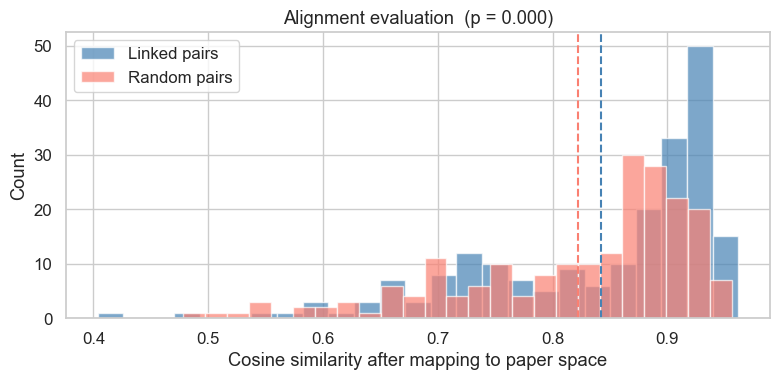

In [13]:
# Evaluate: are linked pairs closer after alignment than random pairs?

# Map validation project embeddings into paper space
X_val_mapped = X_val @ W   # (n_val, 768)

# Similarity between each mapped project and its actual linked paper
linked_sims = np.array([
    cosine_similarity(xm.reshape(1, -1), y.reshape(1, -1))[0, 0]
    for xm, y in zip(X_val_mapped, Y_val)
])

# Baseline: similarity between each mapped project and a random paper
rng = np.random.default_rng(RANDOM_SEED)
rand_idx  = rng.permutation(len(Y_val))
random_sims = np.array([
    cosine_similarity(xm.reshape(1, -1), Y_val[j].reshape(1, -1))[0, 0]
    for xm, j in zip(X_val_mapped, rand_idx)
])

# Mann-Whitney U: are linked similarities stochastically larger than random?
stat, p = stats.mannwhitneyu(linked_sims, random_sims, alternative='greater')

print(f'Linked pairs  — mean cosine similarity: {linked_sims.mean():.4f} (±{linked_sims.std():.4f})')
print(f'Random pairs  — mean cosine similarity: {random_sims.mean():.4f} (±{random_sims.std():.4f})')
print(f'Mann-Whitney U (linked > random):  U={stat:.0f},  p={p:.4f}')

if p < 0.05:
    print('✓ Linked pairs are significantly closer together than random pairs.')
else:
    print('✗ No significant difference detected — alignment may need more anchors.')

# Plot distributions
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(linked_sims, bins=25, alpha=0.7, label='Linked pairs',  color='steelblue')
ax.hist(random_sims, bins=25, alpha=0.7, label='Random pairs',  color='salmon')
ax.axvline(linked_sims.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(random_sims.mean(), color='salmon',    linestyle='--', linewidth=1.5)
ax.set_xlabel('Cosine similarity after mapping to paper space')
ax.set_ylabel('Count')
ax.set_title(f'Alignment evaluation  (p = {p:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'alignment_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Optional: thin MLP adapter (non-linear alignment)
# Only worth training if we have enough anchor pairs.
# A single hidden layer with 512 units is enough — we're not training a deep network,
# just allowing a mild non-linearity beyond the linear map.

MIN_PAIRS_FOR_MLP = 200

if len(X_train) >= MIN_PAIRS_FOR_MLP:
    print(f'Training MLP adapter on {len(X_train)} pairs...')
    mlp = MLPRegressor(
        hidden_layer_sizes=(512,),
        activation='relu',
        max_iter=500,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        verbose=False,
    )
    mlp.fit(X_train, Y_train)

    X_val_mlp = mlp.predict(X_val)
    mlp_sims = np.array([
        cosine_similarity(xm.reshape(1, -1), y.reshape(1, -1))[0, 0]
        for xm, y in zip(X_val_mlp, Y_val)
    ])
    print(f'MLP adapter — mean cosine similarity: {mlp_sims.mean():.4f}')
    print(f'Linear map  — mean cosine similarity: {linked_sims.mean():.4f}')
    use_mlp = mlp_sims.mean() > linked_sims.mean()
    print(f'Using: {"MLP adapter" if use_mlp else "linear map (MLP did not improve)"}')
else:
    use_mlp = False
    print(f'Only {len(X_train)} training pairs — below the {MIN_PAIRS_FOR_MLP} threshold for MLP.')
    print('Using the linear map. Collect more BioBrick links to unlock the MLP upgrade.')

# The function we'll use for projecting any project embedding into paper space
def project_to_paper_space(embs):
    """Map project embeddings (384-d) into paper space (768-d)."""
    if use_mlp:
        return mlp.predict(embs)
    return embs @ W

Training MLP adapter on 823 pairs...
MLP adapter — mean cosine similarity: 0.9203
Linear map  — mean cosine similarity: 0.8420
Using: MLP adapter


## Geographic coherence test

The core thesis claim is that projects and papers in the same city form a local semantic cluster.
After alignment we can test this directly:

1. Map all project embeddings into paper space.
2. Compute **intra-city cosine similarity**: the average similarity between artifacts from the same city.
3. Run a **permutation test**: shuffle city labels 500 times, recompute the score each time.
4. The p-value is the fraction of shuffles that beat the real score.

A significant result (p < 0.05) means cities cluster semantically — not just spatially.
This is the empirical signature of local innovation trajectories.

**What can make this fail:**
- Too many cities with only one artifact (no intra-city pairs to compute).
- City geocoding errors that assign artifacts to the wrong city.
- Not enough anchor pairs to produce a reliable alignment.


Computing observed intra-city similarity...
Observed score: 0.8893
Running permutation test (500 shuffles)...
Null mean:      0.8803  (±0.0009)
Observed:       0.8893
p-value:        0.0000
✓ Cities cluster semantically — consistent with local innovation trajectories.


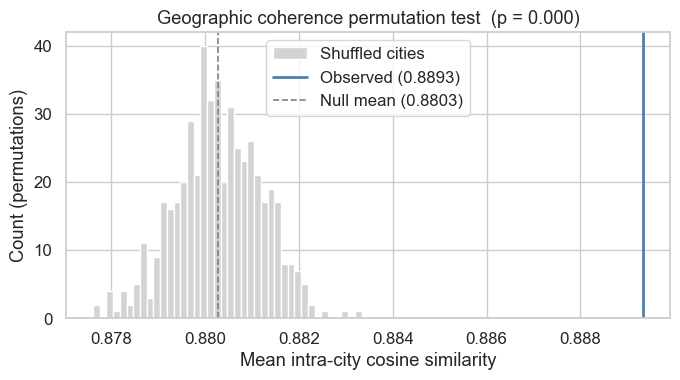

In [15]:
# Map all project embeddings into paper space
all_proj_mapped = project_to_paper_space(project_embs)  # (n_projects, 768)

# Combine with full paper embeddings into one shared space.
# Note: paper_embs_full comes from SPECTER v1 batch files; all_proj_mapped comes from
# the alignment trained on SPECTER2 anchor pairs. The spaces differ slightly.
# Treat results as indicative until the full corpus is re-embedded with SPECTER2.
all_embs   = np.vstack([all_proj_mapped, paper_embs_full])
all_cities = (
    projects['city'].fillna('').tolist() +
    papers_aligned['city'].fillna('').tolist()   # use papers_aligned, not papers
)

def intra_city_score(embs, cities):
    """Average cosine similarity of same-city pairs, across cities with >= 2 artifacts."""
    cities = np.array(cities)
    scores = []
    for city in set(cities):
        if not city:
            continue
        idx = np.where(cities == city)[0]
        if len(idx) < 2:
            continue
        sims = cosine_similarity(embs[idx])
        upper = sims[np.triu_indices(len(idx), k=1)]
        scores.append(upper.mean())
    return np.mean(scores) if scores else 0.0

print('Computing observed intra-city similarity...')
observed = intra_city_score(all_embs, all_cities)
print(f'Observed score: {observed:.4f}')

print('Running permutation test (500 shuffles)...')
rng = np.random.default_rng(RANDOM_SEED)
null_scores = [
    intra_city_score(all_embs, rng.permutation(all_cities))
    for _ in range(500)
]
null_scores = np.array(null_scores)
p_val = (null_scores >= observed).mean()

print(f'Null mean:      {null_scores.mean():.4f}  (±{null_scores.std():.4f})')
print(f'Observed:       {observed:.4f}')
print(f'p-value:        {p_val:.4f}')
if p_val < 0.05:
    print('✓ Cities cluster semantically — consistent with local innovation trajectories.')
else:
    print('✗ No significant geographic clustering detected.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_scores, bins=40, color='lightgray', edgecolor='white', label='Shuffled cities')
ax.axvline(observed, color='steelblue', linewidth=2,
           label=f'Observed ({observed:.4f})')
ax.axvline(null_scores.mean(), color='gray', linestyle='--', linewidth=1.2,
           label=f'Null mean ({null_scores.mean():.4f})')
ax.set_xlabel('Mean intra-city cosine similarity')
ax.set_ylabel('Count (permutations)')
ax.set_title(f'Geographic coherence permutation test  (p = {p_val:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'geographic_permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
np.save(CACHE_DIR / 'alignment_W.npy', W)
np.save(CACHE_DIR / 'projects_in_paper_space.npy', all_proj_mapped)

combined_meta = []

for i, (_, row) in enumerate(projects.iterrows()):
    combined_meta.append({
        'id':              row['id'],
        'type':            'project',
        'title':           row.get('title', ''),
        'year':            int(row['year']) if pd.notna(row.get('year')) else None,
        'city':            row.get('city', ''),
        'country':         row.get('country', ''),
        'case_study_flag': bool(row.get('case_study_flag', False)),
        'proj_emb_index':  i,
        'embedding_source': 'projected_via_W',
    })

for i, (_, row) in enumerate(papers_aligned.iterrows()):
    combined_meta.append({
        'id':              row['id'],
        'type':            'paper',
        'title':           row.get('title', ''),
        'year':            int(row['year']) if pd.notna(row.get('year')) else None,
        'city':            row.get('city', ''),
        'country':         row.get('country', ''),
        'case_study_flag': bool(row.get('case_study_flag', False)),
        'paper_emb_index': i,
        'embedding_source': 'specter_v1_batch',
    })

with open(CACHE_DIR / 'combined_meta.json', 'w') as f:
    json.dump(combined_meta, f, indent=2)

print('Saved to data/embeddings/:')
print(f'  alignment_W.npy              {W.shape}')
print(f'  projects_in_paper_space.npy  {all_proj_mapped.shape}')
print(f'  combined_meta.json           {len(combined_meta)} rows')

Saved to data/embeddings/:
  alignment_W.npy              (384, 768)
  projects_in_paper_space.npy  (4615, 768)
  combined_meta.json           13335 rows


## Summary

This notebook implemented:

| Step | What it does |
|------|--------------|
| Anchor pairs | Link projects to papers via BioBrick part citations (two directions) |
| Project embedding | `all-MiniLM-L6-v2`, 384-d, suited to informal iGEM wiki text |
| Paper embedding | `allenai-specter`, 768-d, trained on scientific literature |
| Linear alignment | OLS least-squares map W (384 → 768) fitted on training anchors |
| Pair test | Mann-Whitney U: are linked pairs closer than random after mapping? |
| Geographic test | Permutation test: do same-city pairs cluster more than chance? |

### File relationships

There are two link types, each with a mapping table and a separate text source:

| | Mapping table | Text source |
|---|---|---|
| **Type A** (team cites paper) | `part_source_papers.csv` (part_name → doi, paper_id) | `papers_from_parts.csv` (paper_id → text) |
| **Type B** (paper mentions part) | `paper_mentions_part.csv` (part_name → doi) | `biobrick_papers.csv` (doi → text) |

Project matching uses the numeric `team_id` from `parts.csv`, resolved to a project ID via
the iGEM teams file — avoiding team name format mismatches entirely.

### Next steps

1. **Cross-subfield evaluation**: train on all except carbon capture, test generalisation on carbon capture alone.
2. **Visualisation**: use `projects_in_paper_space.npy` and `papers_specter.npy` for a shared UMAP projection.
3. **Upgrade to SPECTER2**: if results look promising, swap `allenai-specter` for a proper SPECTER2 adapter.